In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

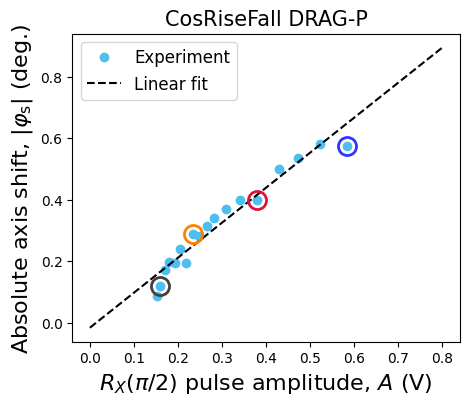

In [2]:
#Re-read csv-files and plot
light_blue = [0.3010, 0.7450, 0.9330]

dark_blue = [51/255,51/255,255/255] #[65,105,225]/255; %royal blue
crimson = [220/255, 20/255, 60/255] 
dark_orange = [255/255, 128/255, 0]
dark_gray = [64/255, 64/255, 64/255]

color_list = [dark_blue, crimson, dark_orange, dark_gray]



axis_shift_for_zero_delay_arr = np.genfromtxt('axis_shift_for_zero_delay_arr.csv', delimiter=',')
pulse_amplitude_arr = np.genfromtxt('pulse_amplitude_arr.csv', delimiter=',')
pulse_duration_arr = np.genfromtxt('pulse_duration_arr.csv', delimiter=',')
#indices corresponding to traces in panel (a)
duration_indices = [0, 4, 10, 16]

fig, ax = plt.subplots(1, 1, figsize=(5,4))
#plt.plot(1/(duration_without_padding_arr_filtr*1e9), axis_angle_diff_vs_zero_pad_mat[duration_without_padding_arr < tg_max_limit, 0], 'o', color=light_blue, label='Experiment') #, label = '%s'%(pulse_leg))
plt.plot(pulse_amplitude_arr , np.abs(axis_shift_for_zero_delay_arr), 'o', color=light_blue, label='Experiment') 
line_params, cov = np.polyfit(pulse_amplitude_arr, np.abs(axis_shift_for_zero_delay_arr), 1, cov=True)
amp_fit_arr = np.linspace(0, 0.8, 10)
plt.plot(amp_fit_arr, line_params[0]*amp_fit_arr + line_params[1], '--', color='k', label='Linear fit') #, label = '%s'%(pulse_leg))
for j, duration_idx in enumerate(duration_indices):
    plt.plot(pulse_amplitude_arr[duration_idx], np.abs(axis_shift_for_zero_delay_arr[duration_idx]), 'o', markerfacecolor="None", markeredgecolor=color_list[j], markersize = 13, markeredgewidth= 2) #, label = '%s'%(pulse_leg))
#plt.xlabel(r'$t_\mathrm{g}^{-1}$ (1/ns)', fontsize = 16)
plt.xlabel(r'$R_X(\pi/2)$ pulse amplitude, $A$ (V)', fontsize = 16)
#plt.ylabel(r'Gate error ($\times 10^{-4}$)', fontsize = 16)
plt.ylabel(r'Absolute axis shift, $|\varphi_\mathrm{s}|$ (deg.)', fontsize = 16)
plt.title('CosRiseFall DRAG-P', fontsize=15)
plt.legend(fontsize = 12, loc = 'upper left')